(a) gamma correction

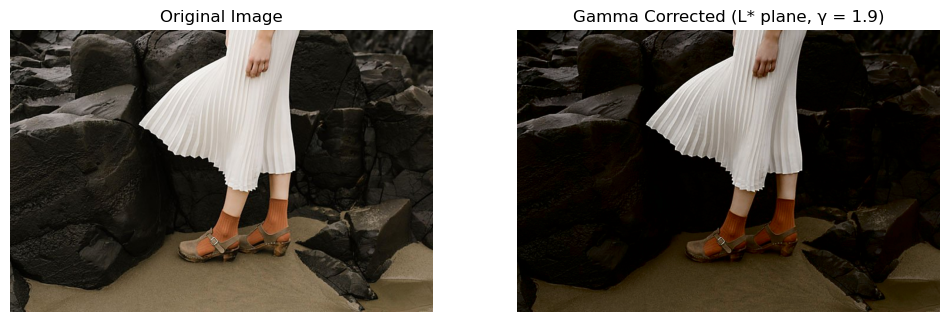

Gamma value used: 1.9


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('highlights_and_shadows.jpg')
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

gamma = 1.9

L_norm = L / 255.0
L_corrected_norm = L_norm ** gamma
L_corrected = (L_corrected_norm * 255).astype(np.uint8)
lab_corrected = cv2.merge([L_corrected, a, b])
img_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_corrected, cv2.COLOR_BGR2RGB))
plt.title(f'Gamma Corrected (L* plane, γ = {gamma})')
plt.axis('off')
plt.show()

print(f"Gamma value used: {gamma}")

(b) histograms of the original and corrected images.

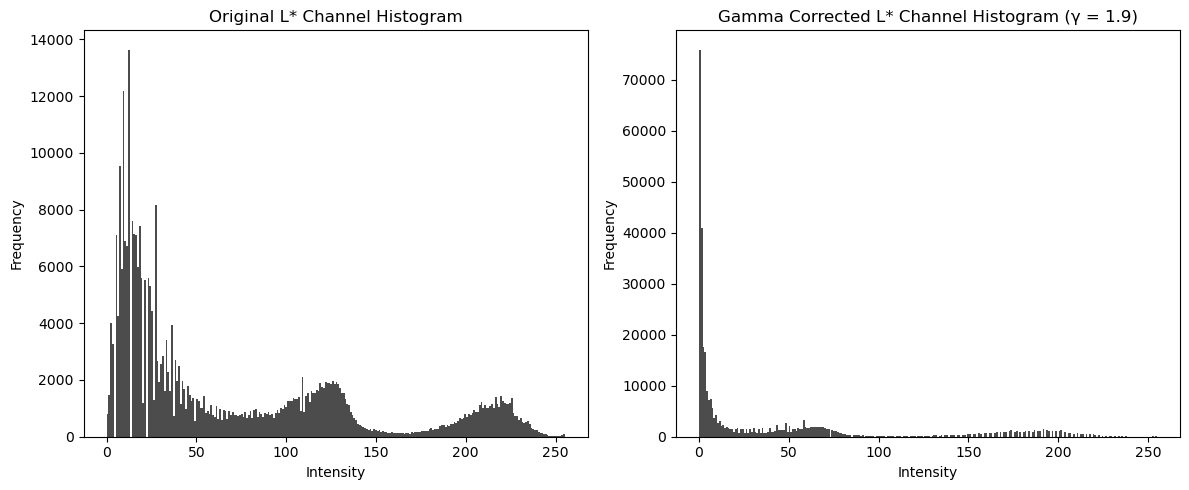

In [4]:
L_original = cv2.split(cv2.cvtColor(img, cv2.COLOR_BGR2LAB))[0]
L_corrected_from_lab = cv2.split(lab_corrected)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(L_original.ravel(), bins=256, range=(0, 255), color='black', alpha=0.7)
plt.title('Original L* Channel Histogram')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(L_corrected_from_lab.ravel(), bins=256, range=(0, 255), color='black', alpha=0.7)
plt.title(f'Gamma Corrected L* Channel Histogram (γ = {gamma})')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()